In [1]:
import importlib.util
import json
import re
import tempfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler

import reservoirpy as rpy
from reservoirpy.hyper import parallel_research, plot_hyperopt_report

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="sklearn.base",
)

movie_name = "AfterTheRain"
target_column = "Throat"
data_root = Path("../data/emofilm")
behav_data = pd.read_csv(data_root / f"Annot_{movie_name}_stim.csv")

timeseries_archive_path = data_root / f"{movie_name}_parcellated_timeseries.npz"

X = np.load(data_root / f"{movie_name}_schaefer200_parcellated_timeseries.npz")
X = [X[f'arr_{i}'] for i in range(len(X.files))]

event_timing_dir = data_root / "event_timings"
event_timing_files = sorted(event_timing_dir.glob(f"sub-*_{movie_name}_events.tsv"))
if len(X) != len(event_timing_files):
    raise ValueError(
        f"Timeseries count ({len(X)}) does not match event timing files ({len(event_timing_files)})."
    )

lag_seconds = 5.0
outer_n_splits = 5
inner_n_splits = 3
cv_random_state = 42
show_hyperopt_plots = False
reservoir_workers = 1
warmup = 20
hyperopt_search_dir = Path("../hyperopt-search")
hyperopt_plot_figsize = (24, 16)
hyperopt_plot_dpi = 100
hyperopt_report_prefix = "hyper-search-report"

hyper_search_config = {
    "exp": f"{movie_name}_{target_column}_nestedcv",
    "hp_max_evals": 20,
    "hp_method": "random",
    "seed": 42,
    "instances_per_trial": 3,
    "hp_space": {
        "N": ["choice", 300, 500],
        "sr": ["loguniform", 1e-2, 1e1],
        "lr": ["loguniform", 1e-3, 1],
        "input_scaling": ["loguniform", 1e-1, 1e1],
        "ridge": ["loguniform", 1e-9, 1e3],
        "seed": ["choice", 1234],
    },
}

helpers_path = Path("../test-predict-random-optim-HP.py").resolve()
helpers_spec = importlib.util.spec_from_file_location("brainhack_reservoir_helpers", helpers_path)
if helpers_spec is None or helpers_spec.loader is None:
    raise ImportError(f"Could not load helper script from {helpers_path}")
helpers = importlib.util.module_from_spec(helpers_spec)
helpers_spec.loader.exec_module(helpers)

prepare_hyperopt_run = helpers.prepare_hyperopt_run
move_hyperopt_results_to_run_dir = helpers.move_hyperopt_results_to_run_dir
build_flat_hyperopt_report_dir = helpers.build_flat_hyperopt_report_dir
build_esn = helpers.build_esn
build_final_esn_with_ridgecv = helpers.build_final_esn_with_ridgecv
predict_test_series = helpers.predict_test_series
compute_metrics = helpers.compute_metrics
RESULT_CALL_RE = helpers.RESULT_CALL_RE


def compute_metrics(y_true_flat, y_pred, y_baseline_flat=None):
    metrics = dict(helpers.compute_metrics(y_true_flat, y_pred, y_baseline_flat))

    y_pred_flat = np.vstack(y_pred)
    metrics["corr"] = float(np.corrcoef(y_true_flat.ravel(), y_pred_flat.ravel())[0, 1])

    if y_baseline_flat is not None:
        metrics["corr_baseline"] = float(
            np.corrcoef(y_true_flat.ravel(), y_baseline_flat.ravel())[0, 1]
        )

        if "srmse" not in metrics:
            metrics["srmse"] = metrics["rmse"] / np.var(y_true_flat)
        if "srmse_baseline" not in metrics:
            metrics["srmse_baseline"] = metrics["rmse_baseline"] / np.var(y_true_flat)

    return metrics


def load_movie_timing(event_timing_path):
    event_table = pd.read_csv(event_timing_path)
    movie_rows = event_table.loc[event_table["trial_type"].eq("film")]
    if movie_rows.empty:
        raise ValueError(f"No film row found in {event_timing_path}")
    movie_row = movie_rows.iloc[0]
    movie_onset = float(movie_row["onset"])
    movie_duration = float(movie_row["duration"])
    run_end = float((event_table["onset"] + event_table["duration"]).max())
    return movie_onset, movie_duration, run_end


def align_fmri_to_movie_window(x_series, event_timing_path, target_length, lag_seconds=5.0):
    movie_onset, movie_duration, run_end = load_movie_timing(event_timing_path)
    x_time = np.linspace(0.0, run_end, num=len(x_series), endpoint=True)
    aligned_times = np.linspace(
        movie_onset + lag_seconds,
        movie_onset + movie_duration + lag_seconds,
        num=target_length,
        endpoint=False,
    )

    aligned = np.empty((target_length, x_series.shape[1]), dtype=float)
    for feature_index in range(x_series.shape[1]):
        aligned[:, feature_index] = np.interp(aligned_times, x_time, x_series[:, feature_index])
    return aligned


def train_and_evaluate_fold(params, dataset, train_positions, val_positions):
    esn = build_esn(**params)
    x_train_fold = [dataset["X_train_scaled_all"][i] for i in train_positions]
    y_train_fold = [dataset["Y_train_scaled_all"][i] for i in train_positions]
    x_val_fold = [dataset["X_train_scaled_all"][i] for i in val_positions]
    y_true_fold = np.hstack([dataset["y_true_single"] for _ in val_positions])

    esn.fit(
        x_train_fold,
        y_train_fold,
        warmup=dataset["warmup"],
        workers=dataset["workers"],
    )

    y_pred = predict_test_series(esn, x_val_fold, dataset["y_scaler"])
    return compute_metrics(y_true_fold, y_pred)


def objective(dataset, config, *, input_scaling, N, sr, lr, ridge, seed):
    instances = config["instances_per_trial"]
    variable_seed = int(seed)

    rmses = []
    maes = []
    r2s = []

    for _ in range(instances):
        params = {
            "N": N,
            "sr": sr,
            "lr": lr,
            "input_scaling": input_scaling,
            "ridge": ridge,
            "seed": variable_seed,
        }

        fold_metrics = [
            train_and_evaluate_fold(params, dataset, train_positions, val_positions)
            for train_positions, val_positions in dataset["inner_splits"]
        ]

        rmses.append(float(np.mean([metrics["rmse"] for metrics in fold_metrics])))
        maes.append(float(np.mean([metrics["mae"] for metrics in fold_metrics])))
        r2s.append(float(np.mean([metrics["r2"] for metrics in fold_metrics])))
        variable_seed += 1

    return {
        "loss": float(np.mean(rmses)),
        "rmse": float(np.mean(rmses)),
        "rmse_std": float(np.std(rmses)),
        "mae": float(np.mean(maes)),
        "r2": float(np.mean(r2s)),
    }


if target_column not in behav_data.columns:
    raise ValueError(f"{target_column!r} not found in behav_data columns: {list(behav_data.columns)}")

movie_behavior = (
    behav_data[target_column]
    .astype(float)
    .interpolate(limit_direction="both")
    .bfill()
    .ffill()
    .to_numpy()
)
movie_target_length = len(movie_behavior)
y_true_single = movie_behavior[1:]
y_baseline_single = movie_behavior[:-1]

x_aligned = [
    align_fmri_to_movie_window(series, timing_file, movie_target_length, lag_seconds=lag_seconds)
    for series, timing_file in zip(X, event_timing_files)
]
subject_ids = np.arange(len(x_aligned))

if len(subject_ids) < 2:
    raise ValueError("Need at least two subjects for nested CV.")

x_all = [series[:-1] for series in x_aligned]
y_all = [y_true_single.reshape(-1, 1) for _ in x_aligned]
y_baseline_all = [y_baseline_single.reshape(-1, 1) for _ in x_aligned]
outer_cv = KFold(n_splits=min(outer_n_splits, len(subject_ids)), shuffle=True, random_state=cv_random_state)
outer_fold_results = []

print(f"Using nested subject-wise CV with {outer_cv.get_n_splits()} outer folds.")
print()

for outer_fold_index, (train_index, test_index) in enumerate(outer_cv.split(subject_ids), start=1):
    train_subject_ids = subject_ids[train_index]
    test_subject_ids = subject_ids[test_index]

    x_train_outer = [x_all[i] for i in train_subject_ids]
    y_train_outer = [y_all[i] for i in train_subject_ids]
    x_test_outer = [x_all[i] for i in test_subject_ids]
    y_baseline_outer = [y_baseline_all[i] for i in test_subject_ids]

    x_scaler = MinMaxScaler(feature_range=(-1, 1))
    x_scaler.fit(np.vstack(x_train_outer))
    x_train_scaled_all = [x_scaler.transform(x) for x in x_train_outer]
    x_test_scaled_outer = [x_scaler.transform(x) for x in x_test_outer]

    y_scaler = MinMaxScaler(feature_range=(-1, 1))
    y_scaler.fit(np.vstack(y_train_outer))
    y_train_scaled_all = [y_scaler.transform(y) for y in y_train_outer]

    y_true_outer_flat = np.hstack([y_true_single for _ in test_subject_ids])
    y_baseline_outer_flat = np.hstack([y_baseline_single for _ in test_subject_ids])

    inner_cv = KFold(
        n_splits=min(inner_n_splits, len(train_subject_ids)),
        shuffle=True,
        random_state=cv_random_state + outer_fold_index,
    )
    inner_splits = list(inner_cv.split(np.arange(len(train_subject_ids))))

    fold_base_config = dict(hyper_search_config)
    fold_base_config["exp"] = f"{movie_name}_{target_column}_outerfold{outer_fold_index:02d}"
    hyperopt_config, fold_experiment_dir = prepare_hyperopt_run(fold_base_config)
    fold_experiment_dir = fold_experiment_dir / f"outer_fold_{outer_fold_index:02d}"
    fold_experiment_dir.mkdir(parents=True, exist_ok=False)
    config_path = fold_experiment_dir / f"{hyperopt_config['exp']}.config.json"
    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(hyperopt_config, f, indent=2)

    dataset = {
        "X_train_scaled_all": x_train_scaled_all,
        "Y_train_scaled_all": y_train_scaled_all,
        "Y_true_flat": y_true_outer_flat,
        "y_scaler": y_scaler,
        "y_true_single": y_true_single,
        "y_baseline_single": y_baseline_single,
        "inner_splits": inner_splits,
        "warmup": warmup,
        "workers": reservoir_workers,
    }

    np.random.seed(hyperopt_config["seed"])
    rpy.set_seed(hyperopt_config["seed"])

    print(f"Outer fold {outer_fold_index}/{outer_cv.get_n_splits()}")
    print(f"Train subjects: {train_subject_ids.tolist()}")
    print(f"Test subjects : {test_subject_ids.tolist()}")
    print(f"Run folder: {fold_experiment_dir}")
    print()

    best_params, best_loss = parallel_research(
        objective,
        dataset,
        config_path,
        fold_experiment_dir,
    )
    move_hyperopt_results_to_run_dir(fold_experiment_dir)

    best_params = {
        "N": int(best_params["N"]),
        "sr": float(best_params["sr"]),
        "lr": float(best_params["lr"]),
        "input_scaling": float(best_params["input_scaling"]),
        "ridge": float(best_params["ridge"]),
        "seed": int(best_params["seed"]),
    }

    alphas = np.logspace(-9, 3, 13)
    final_esn, final_readout = build_final_esn_with_ridgecv(**best_params, alphas=alphas)
    final_esn.fit(
        x_train_scaled_all,
        y_train_scaled_all,
        warmup=warmup,
        workers=reservoir_workers,
    )
    final_predictions = predict_test_series(final_esn, x_test_scaled_outer, y_scaler)
    final_metrics = compute_metrics(y_true_outer_flat, final_predictions, y_baseline_outer_flat)

    outer_fold_results.append({
        "fold": outer_fold_index,
        "train_subjects": train_subject_ids.tolist(),
        "test_subjects": test_subject_ids.tolist(),
        "best_loss": float(best_loss),
        "best_params": best_params,
        "metrics": final_metrics,
        "alpha_selected": float(final_readout.instances.alpha_),
    })

    print(f"Best inner-CV RMSE: {best_loss:.6f}")
    print(f"Outer test RMSE  : {final_metrics['rmse']:.6f}")
    print(f"Outer test Corr  : {final_metrics['corr']:.6f}")
    print(f"Baseline RMSE    : {final_metrics['rmse_baseline']:.6f}")
    print(f"Baseline Corr    : {final_metrics['corr_baseline']:.6f}")
    print(f"Alpha selected by final RidgeCV: {final_readout.instances.alpha_:.1e}")
    print("-" * 80)

outer_summary = pd.json_normalize(outer_fold_results)
summary_table = outer_summary[[
    "metrics.rmse",
    "metrics.srmse",
    "metrics.corr",
    "metrics.rmse_baseline",
    "metrics.srmse_baseline",
    "metrics.corr_baseline",
    "metrics.rmse_ratio",
]].rename(columns={
    "metrics.rmse": "rmse",
    "metrics.srmse": "srmse",
    "metrics.corr": "corr",
    "metrics.rmse_baseline": "rmse_baseline",
    "metrics.srmse_baseline": "srmse_baseline",
    "metrics.corr_baseline": "corr_baseline",
    "metrics.rmse_ratio": "rmse_ratio",
})

print()
print("Nested subject-wise CV summary")
print(summary_table.mean().to_string())
print()
print("Fold-wise results")
print(outer_summary.to_string(index=False))

Using nested subject-wise CV with 5 outer folds.

Outer fold 1/5
Train subjects: [1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 14, 16, 18, 19, 20, 21, 22]
Test subjects : [0, 8, 9, 15, 17]
Run folder: hyperopt-search\AfterTheRain_Throat_outerfold01_2026-06-13_10h32a\outer_fold_01



100%|██████████| 20/20 [00:28<00:00,  1.43s/trial, best loss=0.577]


Best inner-CV RMSE: 0.577389
Outer test RMSE  : 0.640728
Outer test Corr  : 0.332034
Baseline RMSE    : 0.127262
Baseline Corr    : 0.978129
Alpha selected by final RidgeCV: 1.0e+00
--------------------------------------------------------------------------------
Outer fold 2/5
Train subjects: [0, 3, 4, 6, 7, 8, 9, 10, 11, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Test subjects : [1, 2, 5, 12, 13]
Run folder: hyperopt-search\AfterTheRain_Throat_outerfold02_2026-06-13_10h32a\outer_fold_02



100%|██████████| 20/20 [00:20<00:00,  1.04s/trial, best loss=0.576]


Best inner-CV RMSE: 0.575503
Outer test RMSE  : 0.678401
Outer test Corr  : 0.305796
Baseline RMSE    : 0.127262
Baseline Corr    : 0.978129
Alpha selected by final RidgeCV: 1.0e+00
--------------------------------------------------------------------------------
Outer fold 3/5
Train subjects: [0, 1, 2, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 19, 21, 22]
Test subjects : [3, 4, 11, 18, 20]
Run folder: hyperopt-search\AfterTheRain_Throat_outerfold03_2026-06-13_10h33a\outer_fold_03



...

Best inner-CV RMSE: 0.576984
Outer test RMSE  : 0.681714
Outer test Corr  : 0.346577
Baseline RMSE    : 0.127262
Baseline Corr    : 0.978129
Alpha selected by final RidgeCV: 1.0e-01
--------------------------------------------------------------------------------
Outer fold 4/5
Train subjects: [0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20]
Test subjects : [7, 16, 21, 22]
Run folder: hyperopt-search\AfterTheRain_Throat_outerfold04_2026-06-13_10h33a\outer_fold_04



100%|██████████| 20/20 [00:23<00:00,  1.16s/trial, best loss=0.574]


Best inner-CV RMSE: 0.574204
Outer test RMSE  : 0.640247
Outer test Corr  : 0.399673
Baseline RMSE    : 0.127262
Baseline Corr    : 0.978129
Alpha selected by final RidgeCV: 1.0e+00
--------------------------------------------------------------------------------
Outer fold 5/5
Train subjects: [0, 1, 2, 3, 4, 5, 7, 8, 9, 11, 12, 13, 15, 16, 17, 18, 20, 21, 22]
Test subjects : [6, 10, 14, 19]
Run folder: hyperopt-search\AfterTheRain_Throat_outerfold05_2026-06-13_10h33a\outer_fold_05



100%|██████████| 20/20 [00:23<00:00,  1.15s/trial, best loss=0.569]


Best inner-CV RMSE: 0.569130
Outer test RMSE  : 0.692466
Outer test Corr  : 0.211762
Baseline RMSE    : 0.127262
Baseline Corr    : 0.978129
Alpha selected by final RidgeCV: 1.0e+00
--------------------------------------------------------------------------------

Nested subject-wise CV summary
rmse              0.666711
srmse             1.806582
corr              0.319168
rmse_baseline     0.127262
srmse_baseline    0.344840
corr_baseline     0.978129
rmse_ratio        5.238891

Fold-wise results
 fold                                                      train_subjects      test_subjects  best_loss  alpha_selected  best_params.N  best_params.sr  best_params.lr  best_params.input_scaling  best_params.ridge  best_params.seed  metrics.mse  metrics.rmse  metrics.mae  metrics.r2  metrics.mse_baseline  metrics.rmse_baseline  metrics.mae_baseline  metrics.rmse_ratio  metrics.corr  metrics.corr_baseline  metrics.srmse  metrics.srmse_baseline
    1   [1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 14, 1

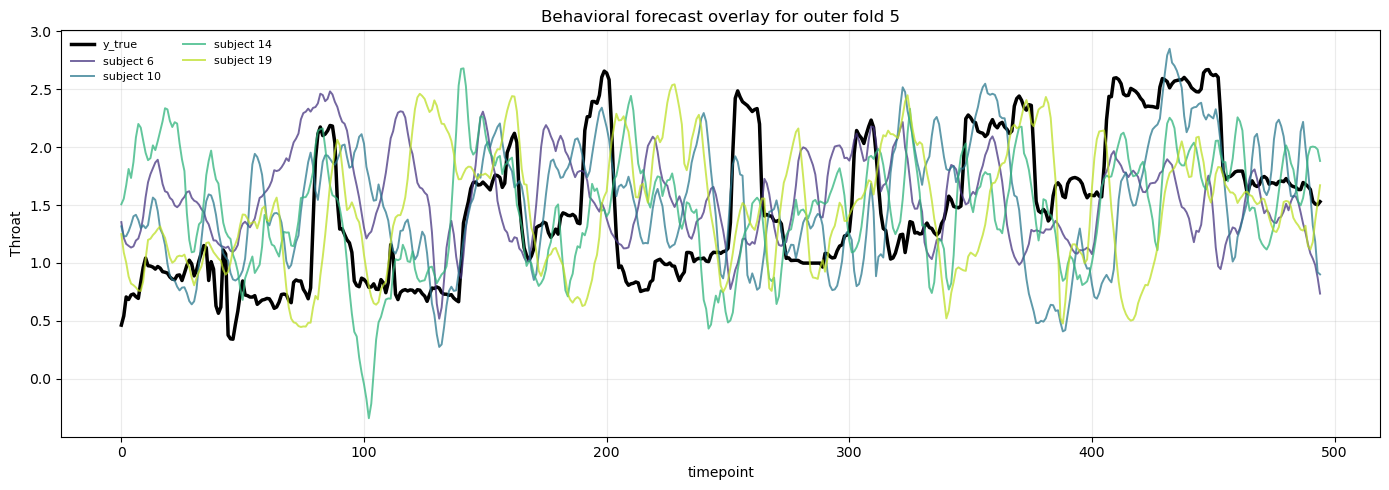

Subject overlay plot saved to: hyperopt-search\AfterTheRain_Throat_outerfold05_2026-06-13_10h33a\outer_fold_05\outer_fold_05_subject_overlay.png


In [2]:
import matplotlib.pyplot as plt

if "final_predictions" not in globals():
    raise RuntimeError("Run the nested CV cell first so final_predictions is available.")

fig, ax = plt.subplots(figsize=(14, 5))
x_axis = np.arange(len(y_true_single))
ax.plot(x_axis, y_true_single, color="black", linewidth=2.5, label="y_true")

color_map = plt.cm.viridis(np.linspace(0.15, 0.9, len(final_predictions))) if len(final_predictions) > 1 else [plt.cm.viridis(0.55)]
for subject_index, y_pred in enumerate(final_predictions):
    subject_label = f"subject {test_subject_ids[subject_index]}"
    ax.plot(x_axis, y_pred.ravel(), color=color_map[subject_index], alpha=0.75, linewidth=1.4, label=subject_label)

ax.set_title(f"Behavioral forecast overlay for outer fold {outer_fold_index}")
ax.set_xlabel("timepoint")
ax.set_ylabel(target_column)
ax.legend(ncol=2, fontsize=8, frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout()

subject_plot_path = fold_experiment_dir / f"outer_fold_{outer_fold_index:02d}_subject_overlay.png"
fig.savefig(subject_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Subject overlay plot saved to: {subject_plot_path}")